In [1]:
import importlib
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import model as model_module
importlib.reload(model_module)
from model import (
    _loocv_final_evaluation,
    plot_feature_importance,
    plot_confusion_mat,
    plot_roc,
    MMSE_COVARIATES,
)

In [2]:
# ── Helper: parse best hyperparameters from a report file ──
def parse_best_params(report_path):
    """Extract best hyperparameters dict from a saved report .txt."""
    with open(report_path) as f:
        content = f.read()
    params = {}
    for m in re.finditer(r'^\s+(n_estimators|max_depth|learning_rate|subsample|colsample_bytree):\s*(.+)$',
                         content, re.MULTILINE):
        key = m.group(1)
        val = m.group(2).strip()
        params[key] = int(val) if key in ('n_estimators', 'max_depth') else float(val)
    return params

# ── Experiment 6 configuration ──
EXP_DIR = Path('experiments/experiment_6')

# All report files in experiment 6
report_files = sorted(EXP_DIR.glob('*_report_*.txt'))
for rf in report_files:
    params = parse_best_params(rf)
    print(f"{rf.name}")
    print(f"  Best params: {params}\n")

2visit_CN_MCI_report_MCI.txt
  Best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.6}

2visit_MCI_AD_report_AD.txt
  Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0}

3visit_CN_MCI_report_MCI.txt
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0}

3visit_MCI_AD_report_AD.txt
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 0.6, 'colsample_bytree': 0.6}

4visit_CN_MCI_report_MCI.txt
  Best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.6}

4visit_MCI_AD_report_AD.txt
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.6}

original_5visit_CN_MCI_report_MCI.txt
  Best params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1,

## Re-run LOOCV and Generate Visualizations

For each experiment 6 model, re-run the LOOCV pipeline with the saved best hyperparameters to collect per-fold predictions and feature importances. Then generate:
1. **Feature Importance** — top-20 bar chart
2. **Confusion Matrix** — annotated heatmap
3. **ROC Curve** — with AUC annotation

In [3]:
# ── Map report files → dataset files ──
DATASET_DIR = Path('datasets/Dataset_final')

tasks = []
for rf in sorted(EXP_DIR.glob('*_report_*.txt')):
    name = rf.stem  # e.g. "3visit_CN_MCI_report_MCI"
    # Extract progression type from the end (after "_report_")
    prog = name.split('_report_')[-1]  # "MCI" or "AD"
    # Dataset base is everything before "_report_"
    base = name.split('_report_')[0]   # e.g. "3visit_CN_MCI"
    csv_path = DATASET_DIR / f"{base}.csv"
    if csv_path.exists():
        tasks.append({
            'report': rf,
            'csv': csv_path,
            'base': base,
            'prog': prog,
            'params': parse_best_params(rf),
        })
        print(f"✓ {base} ({prog}) → {csv_path.name}")
    else:
        print(f"✗ {base} ({prog}) — CSV not found at {csv_path}")

print(f"\n{len(tasks)} models ready for evaluation")

✓ 2visit_CN_MCI (MCI) → 2visit_CN_MCI.csv
✓ 2visit_MCI_AD (AD) → 2visit_MCI_AD.csv
✓ 3visit_CN_MCI (MCI) → 3visit_CN_MCI.csv
✓ 3visit_MCI_AD (AD) → 3visit_MCI_AD.csv
✓ 4visit_CN_MCI (MCI) → 4visit_CN_MCI.csv
✓ 4visit_MCI_AD (AD) → 4visit_MCI_AD.csv
✓ original_5visit_CN_MCI (MCI) → original_5visit_CN_MCI.csv
✓ original_5visit_MCI_AD (AD) → original_5visit_MCI_AD.csv

8 models ready for evaluation



  2visit_CN_MCI (CN→MCI)
  Best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.6}
Running LOOCV final evaluation in parallel (n_jobs=11, 1078 folds)...


LOOCV final evaluation: 100%|██████████| 1078/1078 [04:12<00:00,  4.27fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       998
           1       0.39      0.51      0.44        80

    accuracy                           0.90      1078
   macro avg       0.67      0.72      0.69      1078
weighted avg       0.92      0.90      0.91      1078


ROC AUC Score: 0.8713
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.904 (CI: 0.886, 0.920) range=0.034
- Precision (macro): 0.673 (CI: 0.627, 0.720) range=0.093
- Recall (macro): 0.724 (CI: 0.669, 0.782) range=0.112
- F1 (macro): 0.694 (CI: 0.645, 0.738) range=0.093
- ROC AUC: 0.871 (CI: 0.821, 0.913) range=0.092


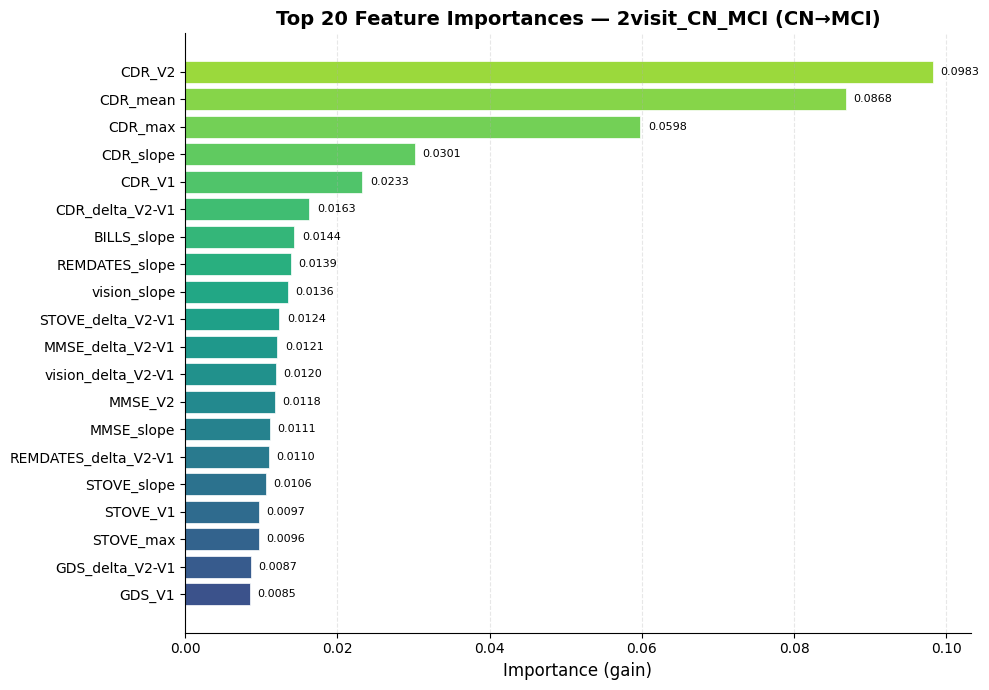

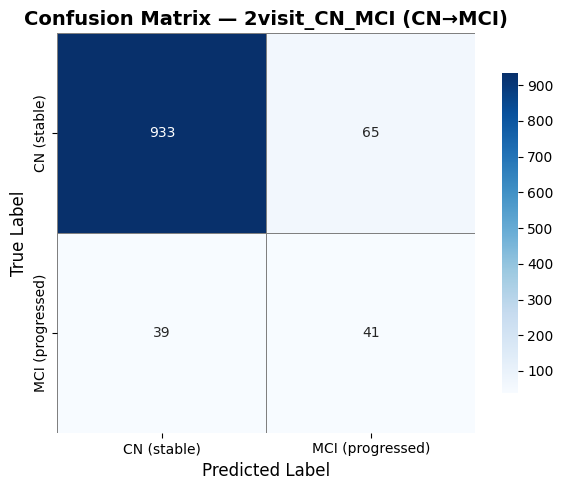

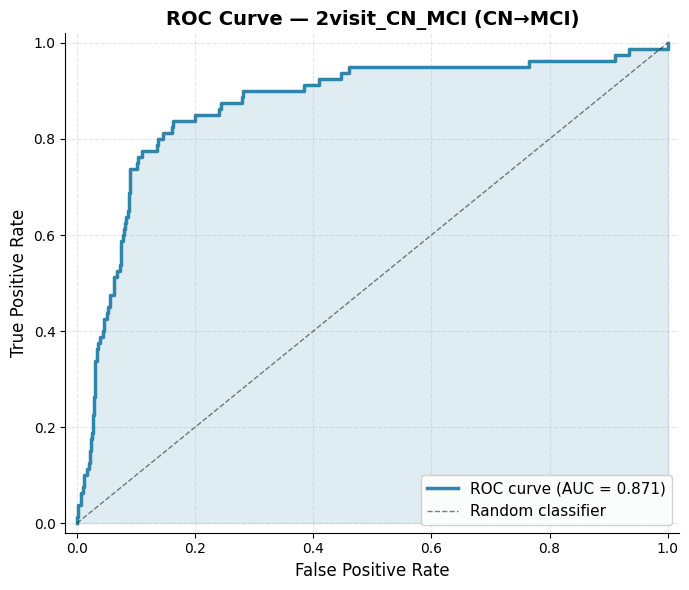


  2visit_MCI_AD (MCI→AD)
  Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0}
Running LOOCV final evaluation in parallel (n_jobs=11, 435 folds)...


LOOCV final evaluation: 100%|██████████| 435/435 [00:38<00:00, 11.44fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.64      0.71      0.68       217
           1       0.68      0.61      0.64       218

    accuracy                           0.66       435
   macro avg       0.66      0.66      0.66       435
weighted avg       0.66      0.66      0.66       435


ROC AUC Score: 0.7434
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.660 (CI: 0.614, 0.703) range=0.090
- Precision (macro): 0.662 (CI: 0.617, 0.705) range=0.088
- Recall (macro): 0.660 (CI: 0.616, 0.702) range=0.086
- F1 (macro): 0.659 (CI: 0.614, 0.701) range=0.088
- ROC AUC: 0.743 (CI: 0.697, 0.789) range=0.091


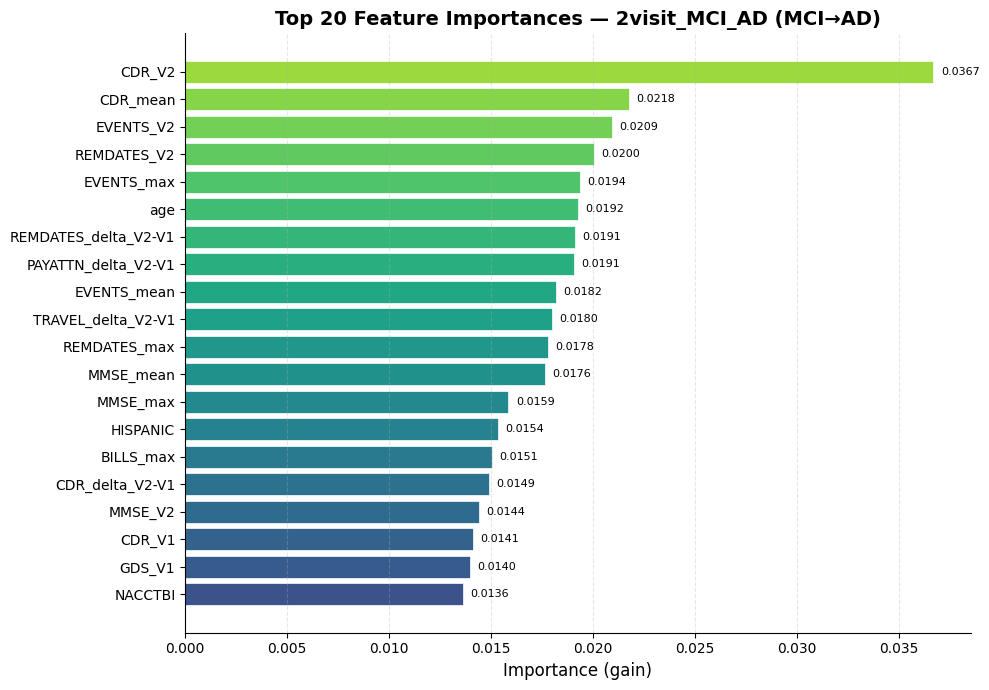

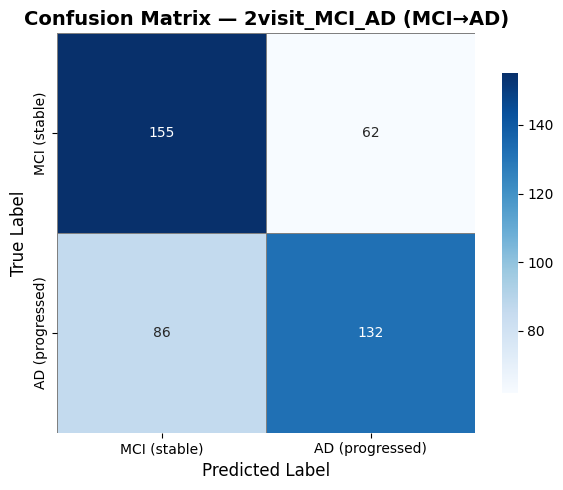

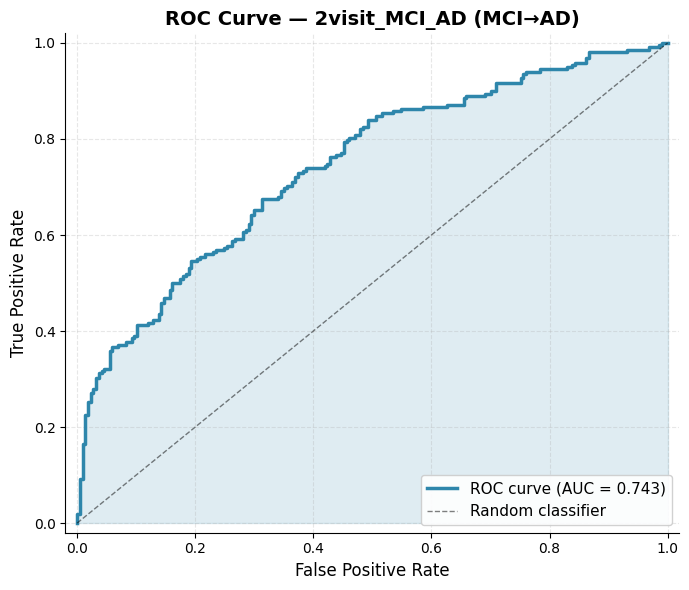


  3visit_CN_MCI (CN→MCI)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0}
Running LOOCV final evaluation in parallel (n_jobs=11, 592 folds)...


LOOCV final evaluation: 100%|██████████| 592/592 [01:14<00:00,  7.91fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       556
           1       0.43      0.44      0.44        36

    accuracy                           0.93       592
   macro avg       0.70      0.70      0.70       592
weighted avg       0.93      0.93      0.93       592


ROC AUC Score: 0.8925
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.931 (CI: 0.910, 0.951) range=0.041
- Precision (macro): 0.698 (CI: 0.622, 0.779) range=0.158
- Recall (macro): 0.703 (CI: 0.625, 0.786) range=0.160
- F1 (macro): 0.701 (CI: 0.627, 0.775) range=0.148
- ROC AUC: 0.893 (CI: 0.817, 0.947) range=0.129


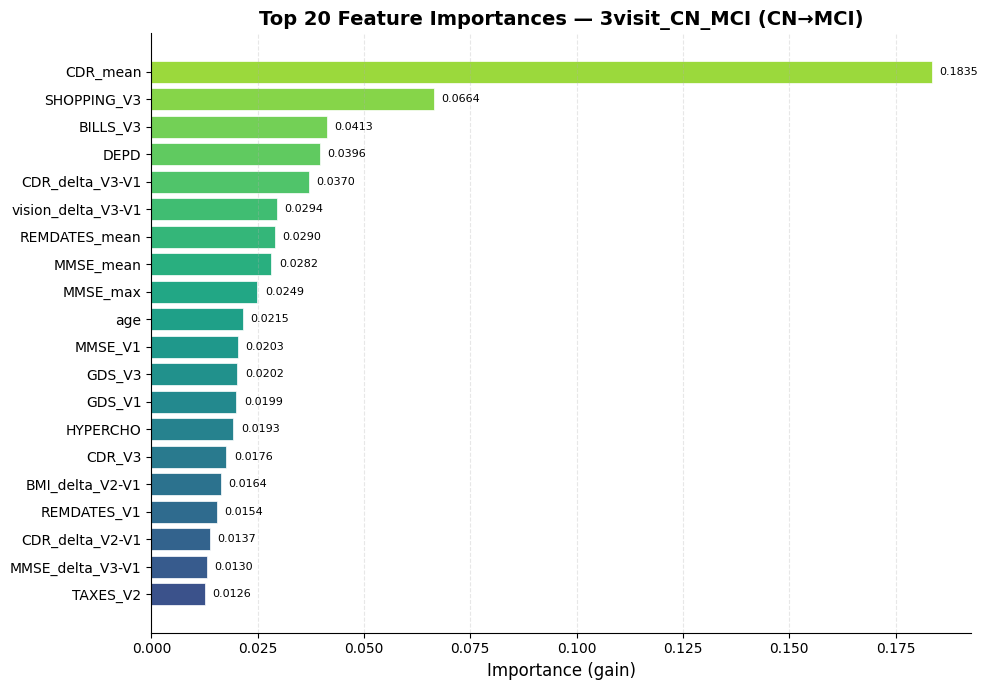

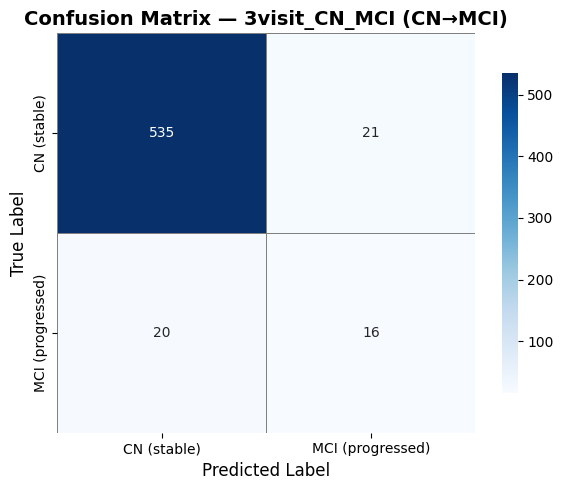

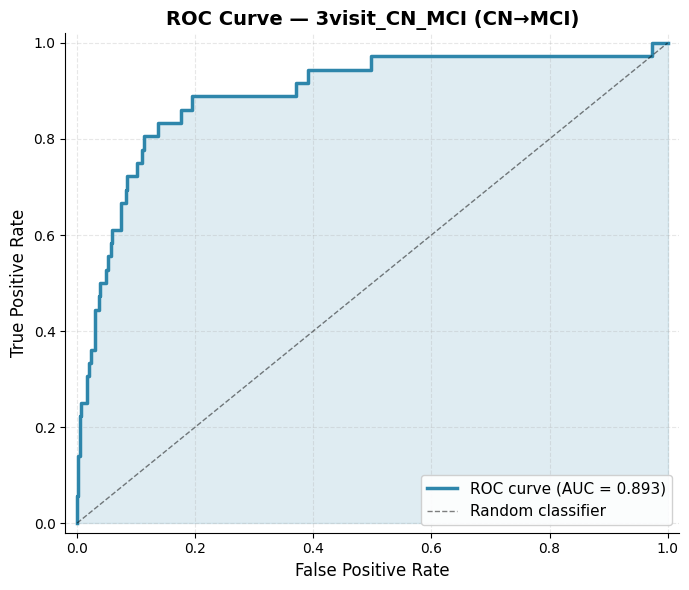


  3visit_MCI_AD (MCI→AD)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 0.6, 'colsample_bytree': 0.6}
Running LOOCV final evaluation in parallel (n_jobs=11, 289 folds)...


LOOCV final evaluation: 100%|██████████| 289/289 [00:17<00:00, 16.68fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.62      0.60      0.61        84
           1       0.84      0.85      0.85       205

    accuracy                           0.78       289
   macro avg       0.73      0.72      0.73       289
weighted avg       0.78      0.78      0.78       289


ROC AUC Score: 0.8198
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.779 (CI: 0.733, 0.827) range=0.094
- Precision (macro): 0.731 (CI: 0.674, 0.793) range=0.119
- Recall (macro): 0.724 (CI: 0.667, 0.784) range=0.117
- F1 (macro): 0.728 (CI: 0.672, 0.784) range=0.112
- ROC AUC: 0.820 (CI: 0.767, 0.870) range=0.103


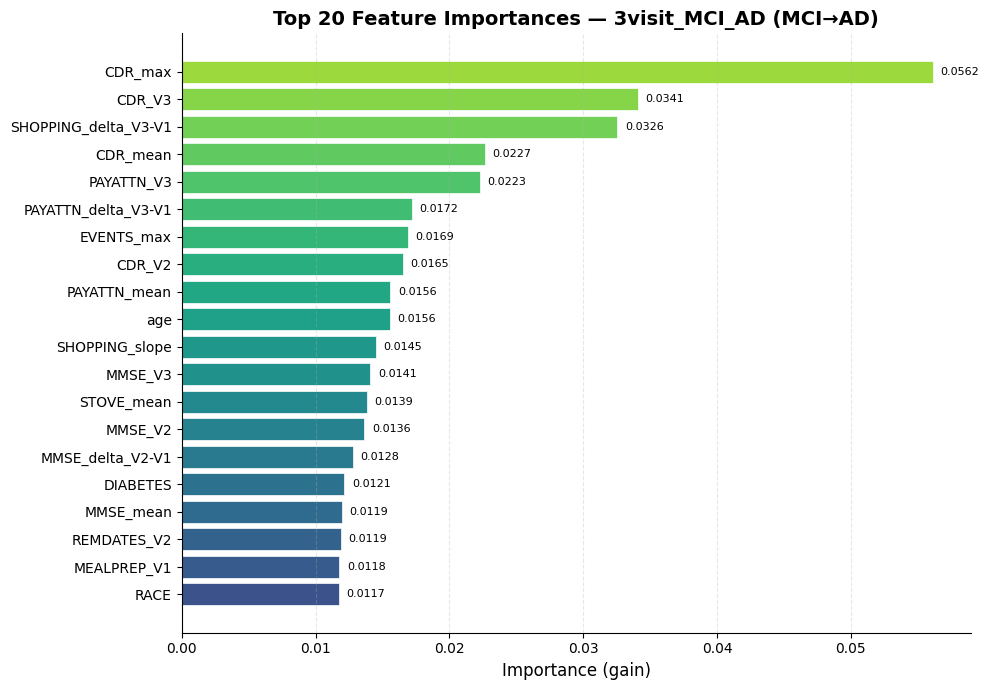

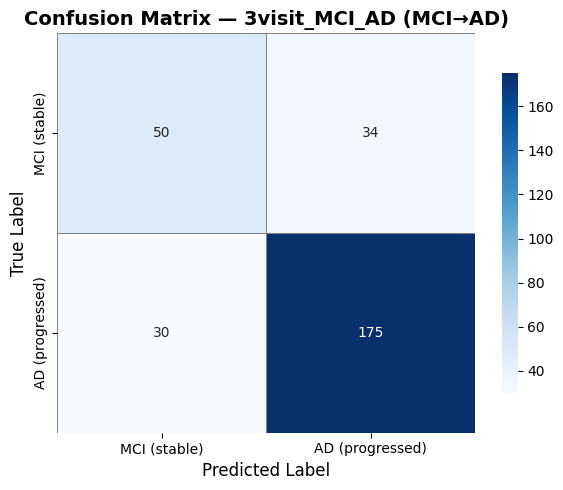

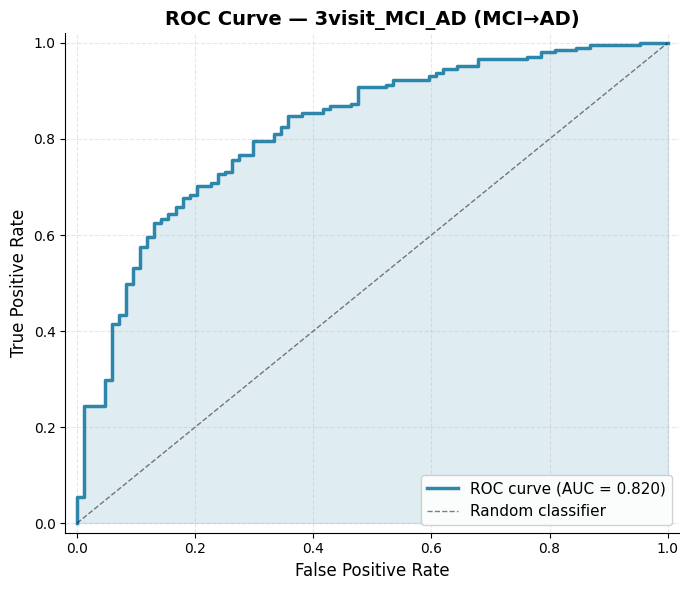


  4visit_CN_MCI (CN→MCI)
  Best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.6}
Running LOOCV final evaluation in parallel (n_jobs=11, 566 folds)...


LOOCV final evaluation:   0%|          | 0/566 [00:00<?, ?fold/s]/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.venv/lib/python3.11/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/aeg00011/Desktop/AD-Research/AD-Early-Prediction/.ve

Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       545
           1       0.56      0.43      0.49        21

    accuracy                           0.97       566
   macro avg       0.77      0.71      0.73       566
weighted avg       0.96      0.97      0.96       566


ROC AUC Score: 0.9620
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.966 (CI: 0.952, 0.981) range=0.028
- Precision (macro): 0.770 (CI: 0.638, 0.895) range=0.257
- Recall (macro): 0.708 (CI: 0.596, 0.822) range=0.227
- F1 (macro): 0.735 (CI: 0.617, 0.832) range=0.215
- ROC AUC: 0.962 (CI: 0.933, 0.985) range=0.052


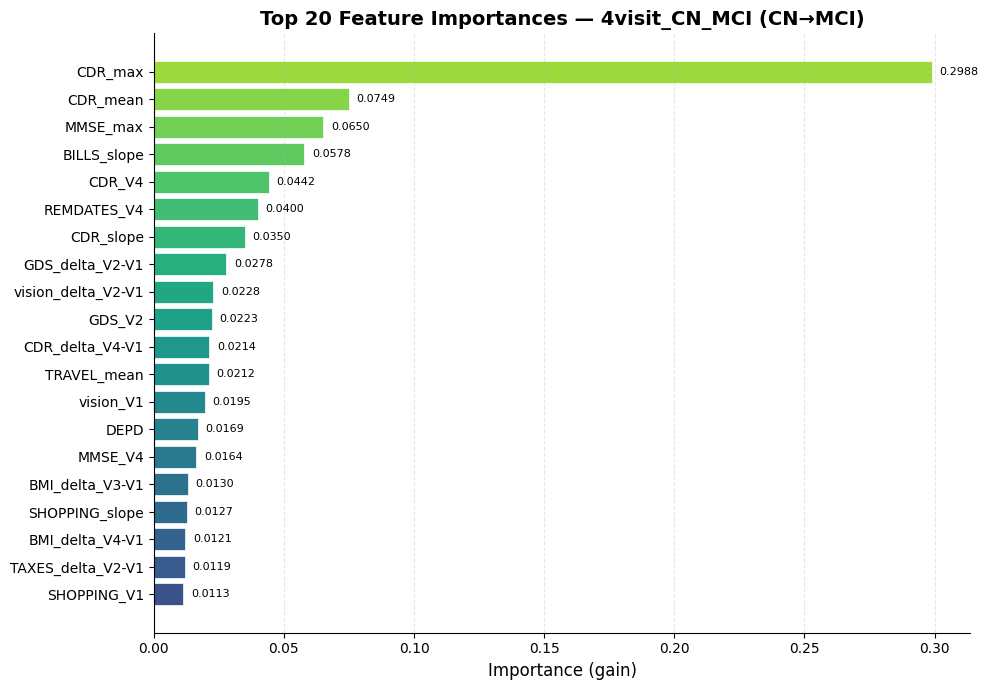

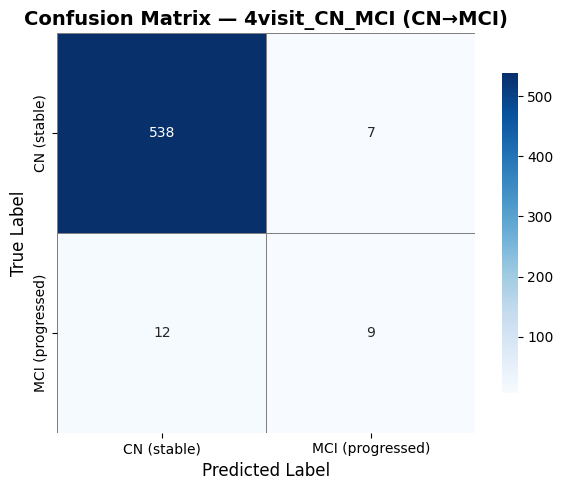

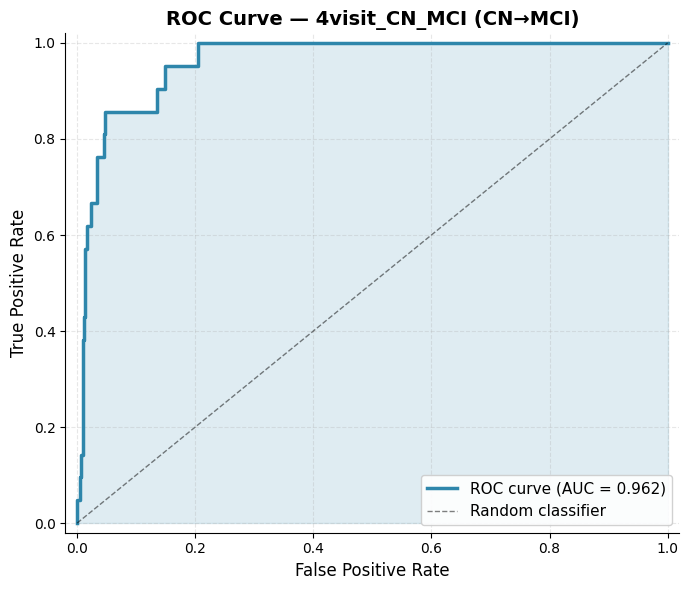


  4visit_MCI_AD (MCI→AD)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.6}
Running LOOCV final evaluation in parallel (n_jobs=11, 226 folds)...


LOOCV final evaluation: 100%|██████████| 226/226 [00:40<00:00,  5.58fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.40      0.64      0.49        36
           1       0.92      0.82      0.87       190

    accuracy                           0.79       226
   macro avg       0.66      0.73      0.68       226
weighted avg       0.84      0.79      0.81       226


ROC AUC Score: 0.8386
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.792 (CI: 0.735, 0.845) range=0.111
- Precision (macro): 0.663 (CI: 0.594, 0.733) range=0.139
- Recall (macro): 0.730 (CI: 0.643, 0.812) range=0.169
- F1 (macro): 0.682 (CI: 0.601, 0.755) range=0.153
- ROC AUC: 0.839 (CI: 0.771, 0.902) range=0.131


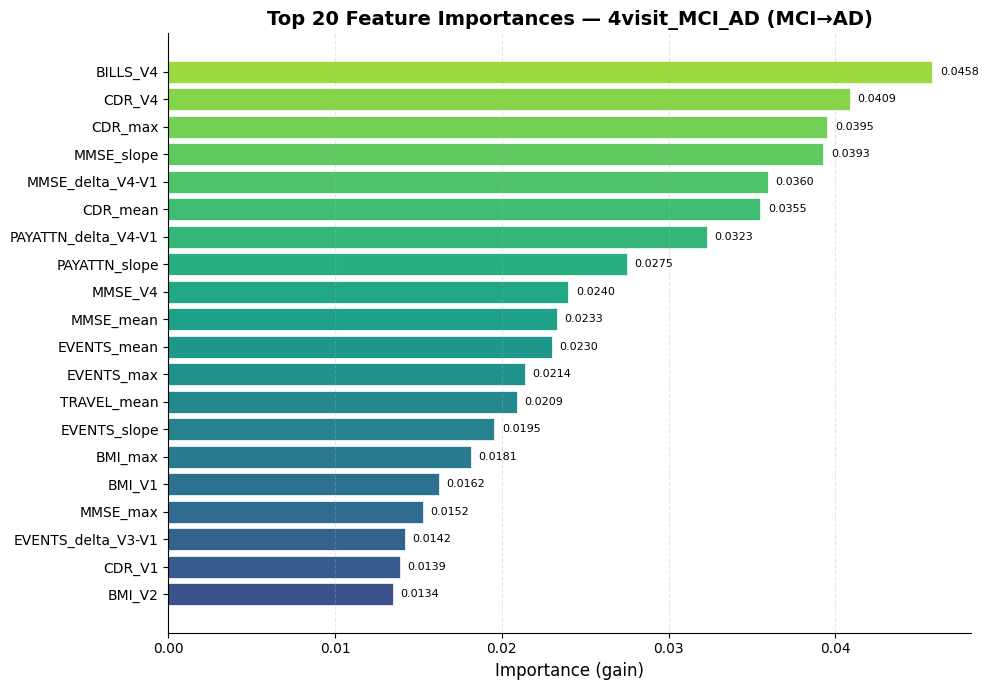

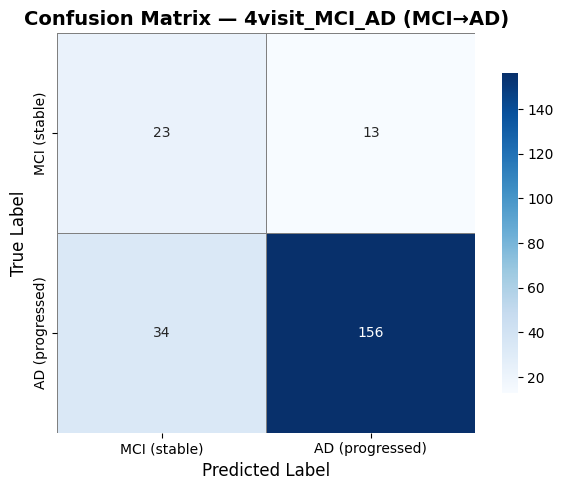

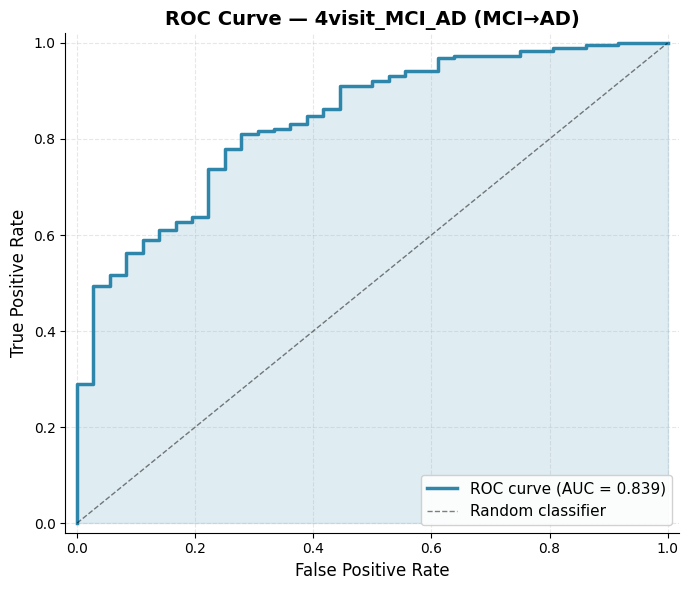


  original_5visit_CN_MCI (CN→MCI)
  Best params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.6, 'colsample_bytree': 0.6}
Running LOOCV final evaluation in parallel (n_jobs=11, 383 folds)...


LOOCV final evaluation: 100%|██████████| 383/383 [02:26<00:00,  2.62fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       370
           1       0.40      0.15      0.22        13

    accuracy                           0.96       383
   macro avg       0.69      0.57      0.60       383
weighted avg       0.95      0.96      0.96       383


ROC AUC Score: 0.7661
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.963 (CI: 0.943, 0.979) range=0.037
- Precision (macro): 0.685 (CI: 0.482, 0.984) range=0.503
- Recall (macro): 0.573 (CI: 0.493, 0.686) range=0.193
- F1 (macro): 0.602 (CI: 0.489, 0.731) range=0.243
- ROC AUC: 0.766 (CI: 0.598, 0.903) range=0.305


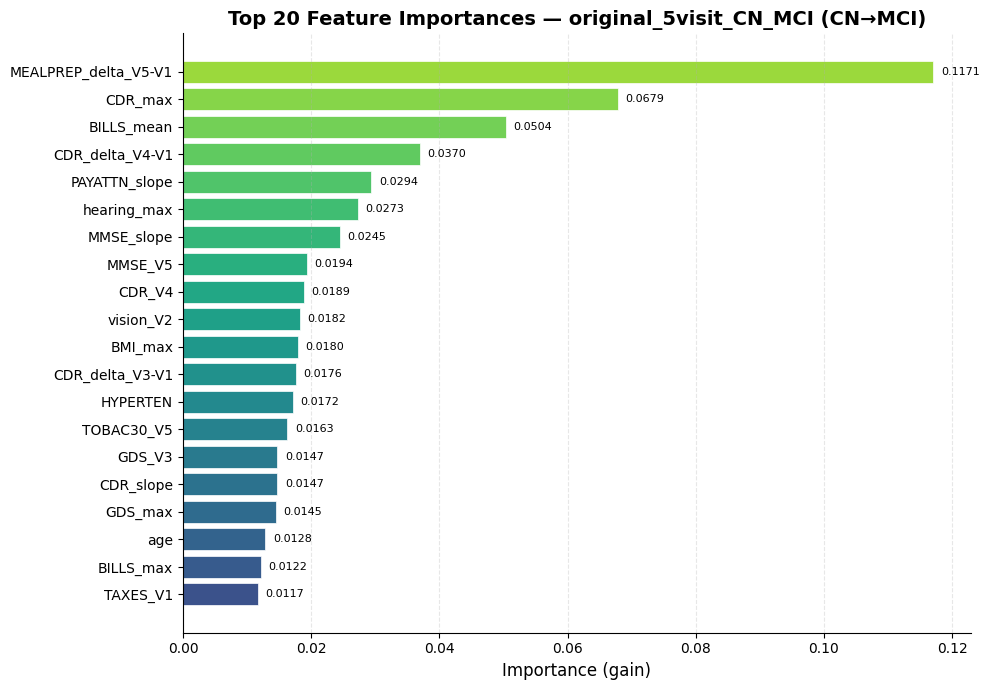

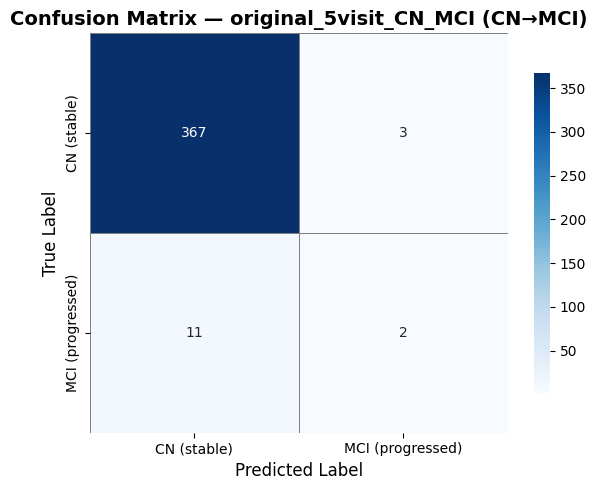

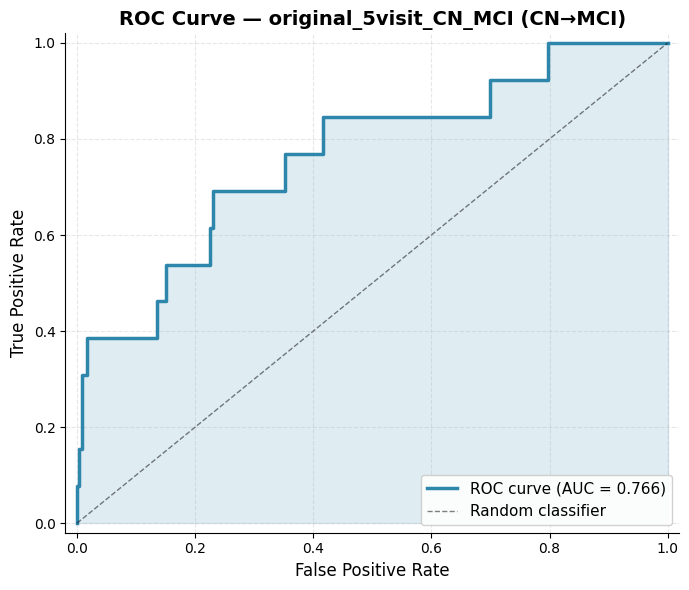


  original_5visit_MCI_AD (MCI→AD)
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.8}
Running LOOCV final evaluation in parallel (n_jobs=11, 120 folds)...


LOOCV final evaluation: 100%|██████████| 120/120 [00:18<00:00,  6.60fold/s]


Classification Report (LOOCV):
              precision    recall  f1-score   support

           0       0.53      0.80      0.64        10
           1       0.98      0.94      0.96       110

    accuracy                           0.93       120
   macro avg       0.76      0.87      0.80       120
weighted avg       0.94      0.93      0.93       120


ROC AUC Score: 0.9518
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.925 (CI: 0.875, 0.967) range=0.092
- Precision (macro): 0.757 (CI: 0.618, 0.889) range=0.271
- Recall (macro): 0.868 (CI: 0.727, 0.978) range=0.251
- F1 (macro): 0.799 (CI: 0.650, 0.908) range=0.258
- ROC AUC: 0.952 (CI: 0.897, 0.991) range=0.094


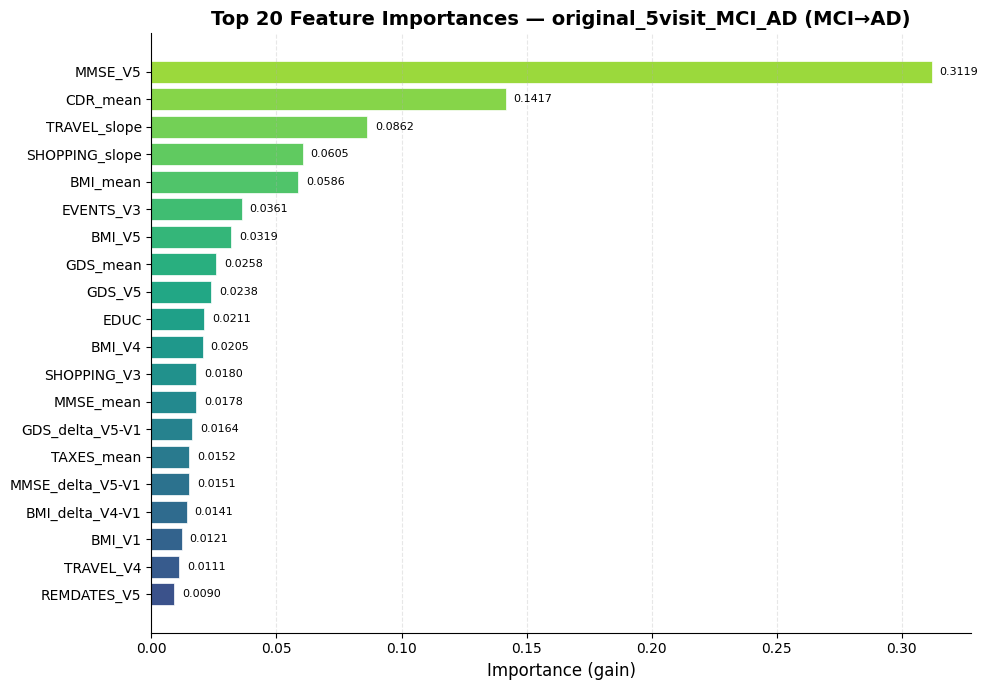

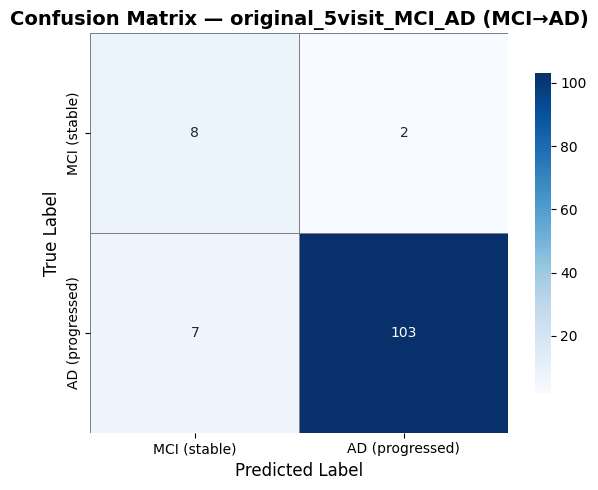

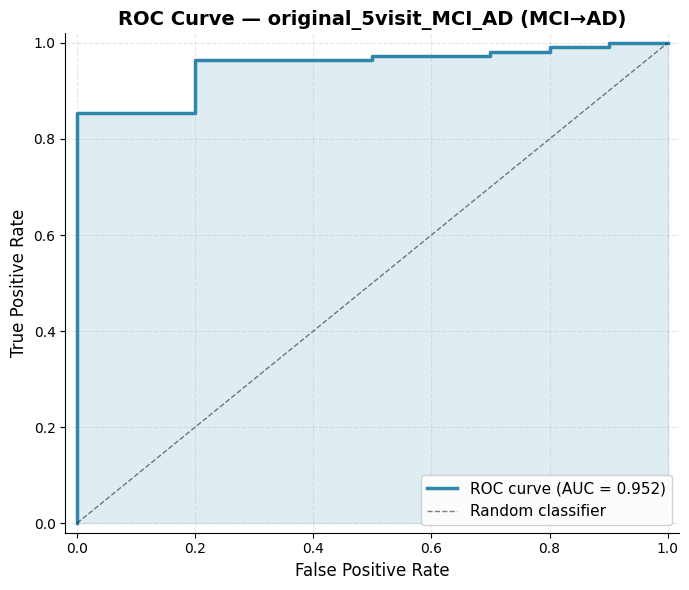


All figures saved to: experiments/experiment_6/figures/


In [5]:
# ── Run LOOCV for each model and produce all 3 visualizations ──
# This re-runs the full per-fold pipeline (MMSE impute → delta features →
# preprocess → impute/scale → XGBoost) with the SAVED best hyperparameters
# to collect predictions + feature importances.
#
# Change tasks_to_run to `tasks` to run all models.

from model import create_target_variable_mci, create_target_variable_ad

N_JOBS = 11  # Number of parallel workers for LOOCV folds
tasks_to_run = tasks  # Single model test — change to `tasks` for all

save_dir = Path('experiments/experiment_6/figures')
save_dir.mkdir(parents=True, exist_ok=True)

all_summaries = {}

for t in tasks_to_run:
    base, prog, params = t['base'], t['prog'], t['params']
    label = f"{base} ({'CN→MCI' if prog == 'MCI' else 'MCI→AD'})"
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  Best params: {params}")
    print(f"{'='*60}")

    # Load and prepare dataset
    df = pd.read_csv(t['csv'])
    if prog == 'AD':
        df['target'] = df.apply(create_target_variable_ad, axis=1)
    else:
        df['target'] = df.apply(create_target_variable_mci, axis=1)

    covariates = [c for c in MMSE_COVARIATES if c in df.columns]
    mmse_needs_imputation = (
        'MMSE' in df.columns
        and df['MMSE'].astype(str).str.contains('nan', na=False).any()
    )

    # Run LOOCV final evaluation — collects y_true, y_proba, y_pred, importances
    summary = _loocv_final_evaluation(
        df, params, covariates, mmse_needs_imputation,
        use_smote=False, progression_type=prog,
        n_jobs=N_JOBS,
    )
    all_summaries[base] = summary

    # Class labels for display
    if prog == 'MCI':
        cls_labels = ['CN (stable)', 'MCI (progressed)']
    else:
        cls_labels = ['MCI (stable)', 'AD (progressed)']

    # 1. Feature Importance
    plot_feature_importance(
        summary['feature_importances'],
        summary['feature_names'],
        top_n=20,
        title=f'Top 20 Feature Importances — {label}',
        save_path=str(save_dir / f'{base}_feature_importance.png'),
    )

    # 2. Confusion Matrix
    plot_confusion_mat(
        summary['y_true'],
        summary['y_pred'],
        class_labels=cls_labels,
        title=f'Confusion Matrix — {label}',
        save_path=str(save_dir / f'{base}_confusion_matrix.png'),
    )

    # 3. ROC Curve
    plot_roc(
        summary['y_true'],
        summary['y_proba'],
        title=f'ROC Curve — {label}',
        save_path=str(save_dir / f'{base}_roc_curve.png'),
    )

print(f"\n{'='*60}")
print(f"All figures saved to: {save_dir}/")
print(f"{'='*60}")

In [6]:
# ── Summary: top-10 features per model side by side ──
print("Top-10 Features by Mean Importance (averaged across LOOCV folds)")
print("=" * 80)

for name, s in all_summaries.items():
    fi = pd.DataFrame({
        'Feature': s['feature_names'],
        'Importance': s['feature_importances'],
    }).sort_values('Importance', ascending=False).head(10).reset_index(drop=True)
    fi.index = fi.index + 1
    prog_label = 'CN→MCI' if 'CN_MCI' in name else 'MCI→AD'
    print(f"\n{name} ({prog_label})")
    print(fi.to_string())

Top-10 Features by Mean Importance (averaged across LOOCV folds)

2visit_CN_MCI (CN→MCI)
              Feature  Importance
1              CDR_V2    0.098269
2            CDR_mean    0.086799
3             CDR_max    0.059806
4           CDR_slope    0.030134
5              CDR_V1    0.023275
6     CDR_delta_V2-V1    0.016332
7         BILLS_slope    0.014363
8      REMDATES_slope    0.013932
9        vision_slope    0.013550
10  STOVE_delta_V2-V1    0.012389

2visit_MCI_AD (MCI→AD)
                 Feature  Importance
1                 CDR_V2    0.036700
2               CDR_mean    0.021768
3              EVENTS_V2    0.020936
4            REMDATES_V2    0.020040
5             EVENTS_max    0.019360
6                    age    0.019250
7   REMDATES_delta_V2-V1    0.019113
8    PAYATTN_delta_V2-V1    0.019085
9            EVENTS_mean    0.018190
10    TRAVEL_delta_V2-V1    0.017999

3visit_CN_MCI (CN→MCI)
               Feature  Importance
1             CDR_mean    0.183503
2          S

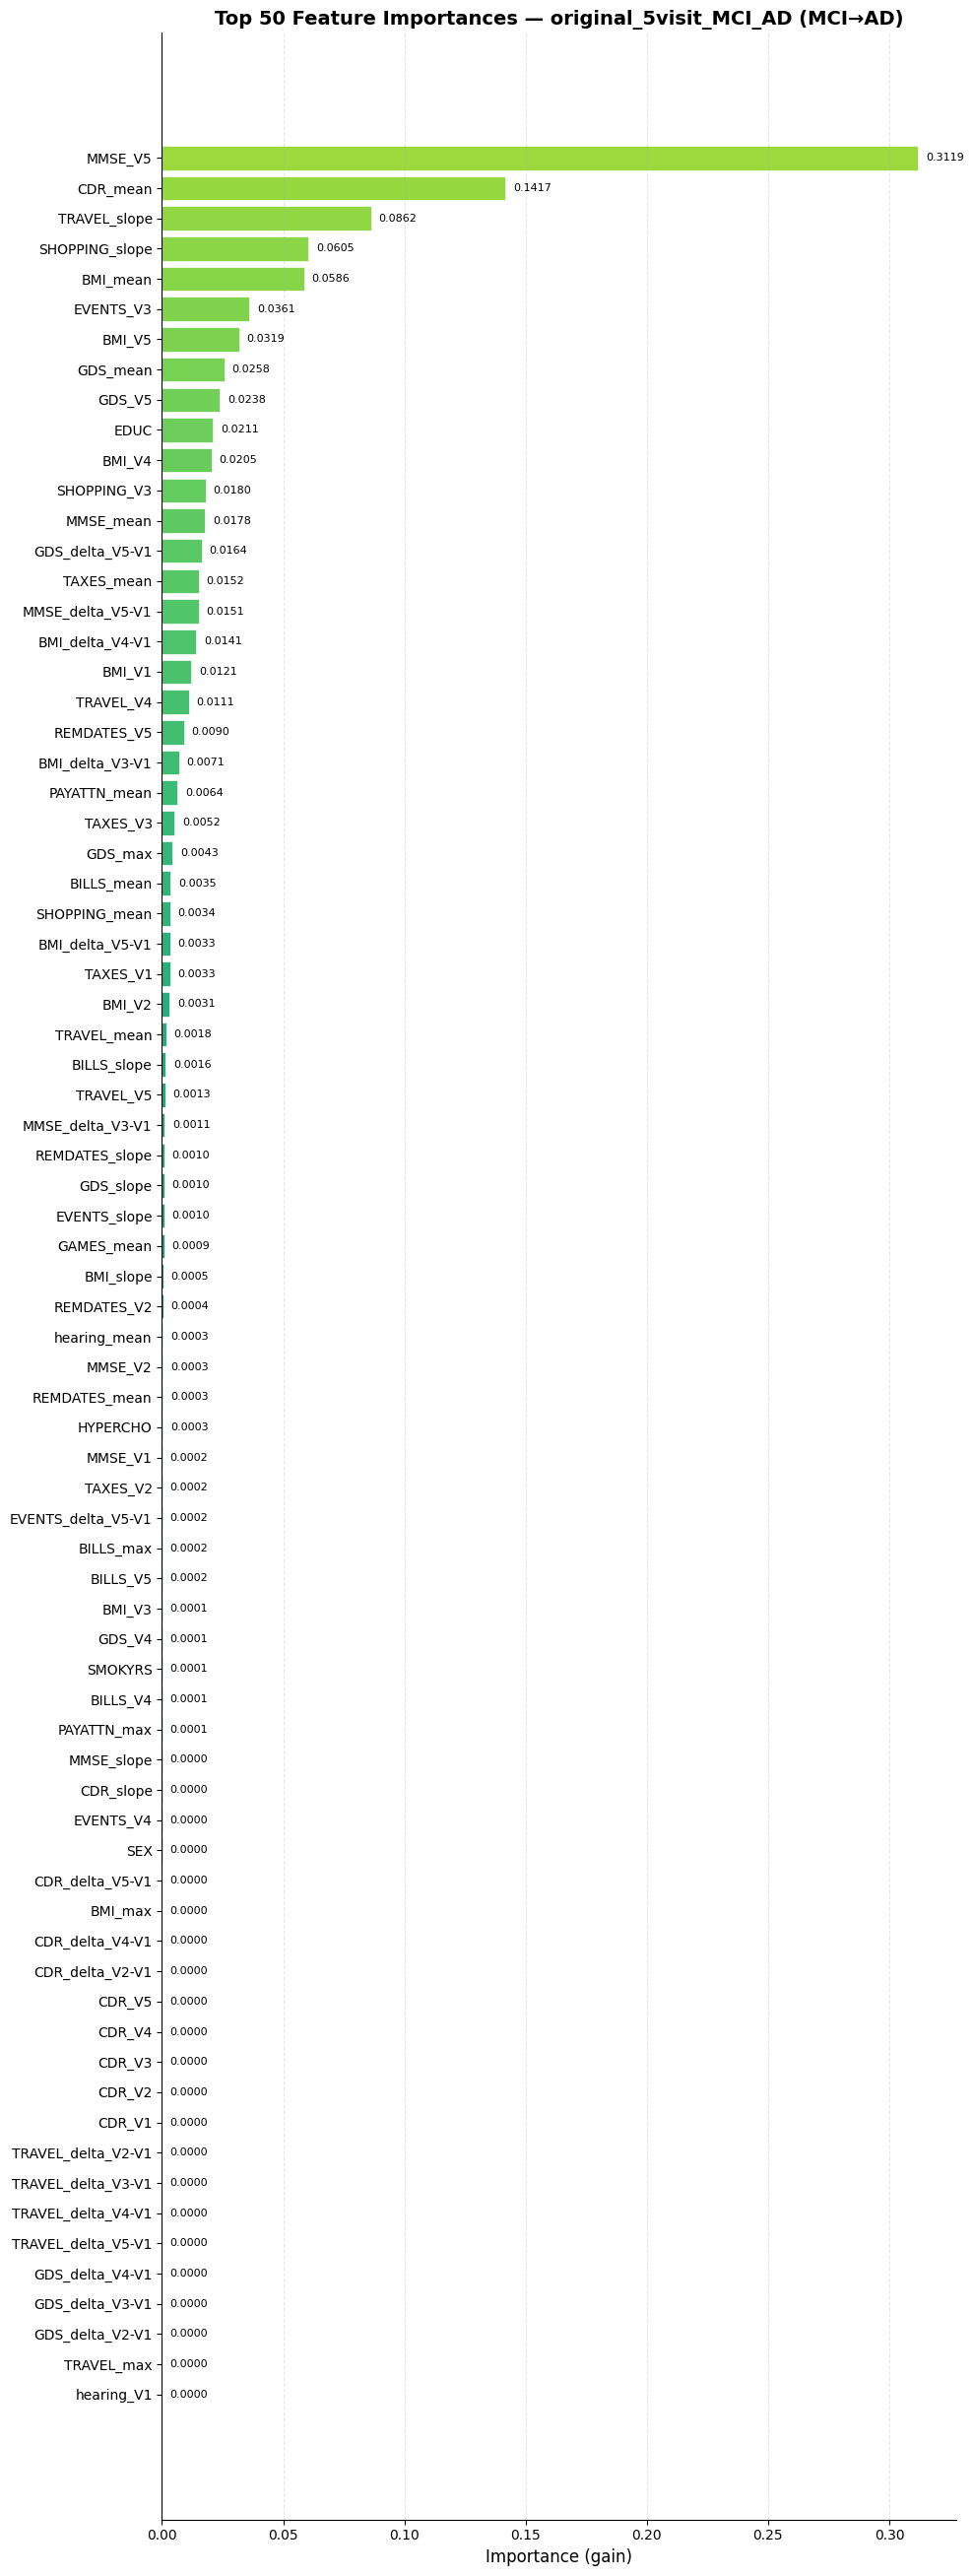

In [8]:
    plot_feature_importance(
        summary['feature_importances'],
        summary['feature_names'],
        top_n=75,
        title=f'Top 50 Feature Importances — {label}',
        save_path=str(save_dir / f'{base}_feature_importance.png'),
    )